Unrestricted Decision Tree
Training Accuracy: 0.9831
Testing Accuracy: 0.7598

Shallow Decision Tree
Training Accuracy: 0.8258
Testing Accuracy: 0.7765



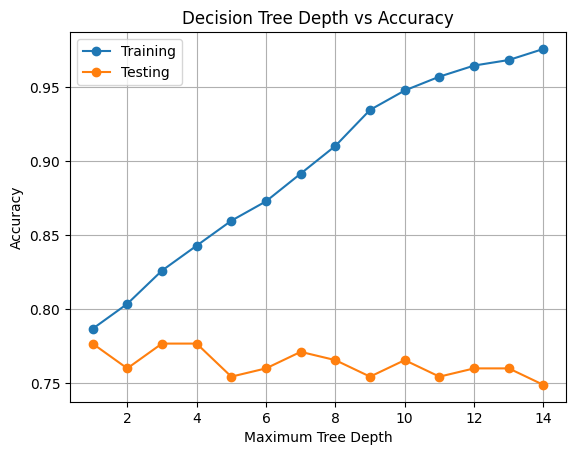

Cost-Complexity Pruned Tree
Training Accuracy: 0.8408
Testing Accuracy: 0.7821

Best ccp_alpha: 0.0056108354259692544
Best Validation Accuracy: 0.848314606741573


In [4]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

df = pd.read_csv("Titanic-Dataset.csv")
df.columns = df.columns.str.lower()

features = ["pclass", "sex", "age", "sibsp",
            "parch", "fare", "embarked"]

X = df[features]
y = df["survived"]

numeric = X.select_dtypes(include="number").columns
categorical = X.select_dtypes(exclude="number").columns

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25,
    random_state=42, stratify=y_train
)

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

def evaluate(model, name):
    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train, model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test, model.predict(X_test)
    )

    print(f"{name}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print()

    return train_acc, test_acc

unrestricted = DecisionTreeClassifier(random_state=42)
evaluate(unrestricted, "Unrestricted Decision Tree")

shallow = DecisionTreeClassifier(
    max_depth=3, random_state=42
)
evaluate(shallow, "Shallow Decision Tree")

depths = range(1, 15)
train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth, random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        accuracy_score(y_train, model.predict(X_train))
    )

    test_scores.append(
        accuracy_score(y_test, model.predict(X_test))
    )

plt.plot(depths, train_scores, marker="o", label="Training")
plt.plot(depths, test_scores, marker="o", label="Testing")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.legend()
plt.grid()
plt.show()

base_tree = DecisionTreeClassifier(random_state=42)

path = base_tree.cost_complexity_pruning_path(
    X_train, y_train
)

best_alpha = 0
best_val_accuracy = 0

for alpha in path.ccp_alphas:
    model = DecisionTreeClassifier(
        ccp_alpha=alpha, random_state=42
    )

    model.fit(X_train, y_train)

    val_accuracy = accuracy_score(
        y_val, model.predict(X_val)
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_alpha = alpha

pruned = DecisionTreeClassifier(
    ccp_alpha=best_alpha, random_state=42
)

evaluate(pruned, "Cost-Complexity Pruned Tree")

print("Best ccp_alpha:", best_alpha)
print("Best Validation Accuracy:", best_val_accuracy)
